#1 Import Library

In [ ]:
# Standard libraries for data analysis:
import numpy as np
import pandas as pd
pd.options.display.max_columns = None
from pandas.plotting import scatter_matrix
from scipy.stats import norm, skew

# sklearn modules for data preprocessing
from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler,
)
from sklearn.model_selection import train_test_split

# sklearn modules for Model Selection
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


# sklearn modules for Model Evaluation & Improvement
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    fbeta_score
)

from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import (
    cross_val_score,
    GridSearchCV,
    ShuffleSplit,
    KFold
)

# Standard libraries for data visualization
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import seaborn as sns
%matplotlib inline
color = sns.color_palette()
import matplotlib.ticker as mtick
from IPython.display import display

# Miscellaneous Utilitiy Libraries
import random
from datetime import datetime
import string

#2 Import dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Import the dataset
file_dir = "/content/drive/MyDrive/Gcolab/Conqueror project/customer_churn_data (1).csv" # Sesuaikan!
dataset = pd.read_csv(file_dir)

# Read Dataset
dataset.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


#3 Overview data

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
dataset.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


##3.1 check missing data

In [ ]:
dataset.describe()


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


totalcharge harusnya masuk ke data float

##3.2 cek duplikat

In [ ]:
dataset.duplicated().sum()

np.int64(0)

#4 Cleaning Data

In [ ]:
dataset.dtypes


,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


total charge harusnya tipenya float

In [ ]:
dataset['TotalCharges'] = pd.to_numeric(dataset['TotalCharges'], errors='coerce')

dataset['TotalCharges'] = dataset['TotalCharges'].astype("float")

Total Charge suda diubah ke float

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


di Total charge ada yg data yg kosong

In [ ]:
dataset[dataset['TotalCharges'].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


karna setelah dicek tenure dengan MonthlyCharge ada selisih ditotal charge maka akan di fillna mothlycharge kali tenure



In [ ]:
dataset['TotalCharges'] = dataset['TotalCharges'].fillna((dataset['MonthlyCharges']*dataset['tenure']))

oke sudah diisi data yg kosong sekarang dicek lagi

In [ ]:
dataset[dataset['TotalCharges'].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


## 4.1 Target variabel

In [ ]:
dataset['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [ ]:
dataset['Churn'].value_counts(normalize=True)

,proportion
Churn,
No,0.73463
Yes,0.26537


Ketidakseimbangan pada data training 73% Reatained (Curtomer bertahan) , 26% Chrn (Keluar, ga lagi beli)


---
Harus ditangani Oversampling SMOTE


## 4.2 rubah encoding

In [ ]:
# kapan label encoding & One hot encoding

gunakan label ketika data kategorikalnya memiliki urutan ordinal kak, kalau one hot itu datanya urutan nominal(gender)

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
dataset_new = pd.get_dummies(dataset, columns=["gender", "Partner", "Dependents", "PhoneService", "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies", "Contract", "PaperlessBilling", "PaymentMethod"], dtype=int)

In [ ]:
dataset_new

,customerID,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,PhoneService_No,PhoneService_Yes,MultipleLines_No,MultipleLines_No phone service,MultipleLines_Yes,InternetService_DSL,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0,1,29.85,29.85,No,1,0,0,1,1,0,1,0,0,1,0,1,0,0,1,0,0,0,0,1,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,1,0
1,5575-GNVDE,0,34,56.95,1889.50,No,0,1,1,0,1,0,0,1,1,0,0,1,0,0,0,0,1,1,0,0,0,0,1,1,0,0,1,0,0,1,0,0,0,1,0,1,0,0,0,0,1
2,3668-QPYBK,0,2,53.85,108.15,Yes,0,1,1,0,1,0,0,1,1,0,0,1,0,0,0,0,1,0,0,1,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,0,1
3,7795-CFOCW,0,45,42.30,1840.75,No,0,1,1,0,1,0,1,0,0,1,0,1,0,0,0,0,1,1,0,0,0,0,1,0,0,1,1,0,0,1,0,0,0,1,0,1,0,1,0,0,0
4,9237-HQITU,0,2,70.70,151.65,Yes,1,0,1,0,1,0,0,1,1,0,0,0,1,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,0,24,84.80,1990.50,No,0,1,0,1,0,1,0,1,0,0,1,1,0,0,0,0,1,1,0,0,0,0,1,0,0,1,0,0,1,0,0,1,0,1,0,0,1,0,0,0,1
7039,2234-XADUH,0,72,103.20,7362.90,No,1,0,0,1,0,1,0,1,0,0,1,0,1,0,1,0,0,0,0,1,0,0,1,1,0,0,0,0,1,0,0,1,0,1,0,0,1,0,1,0,0
7040,4801-JZAZL,0,11,29.60,346.45,No,1,0,0,1,0,1,1,0,0,1,0,1,0,0,0,0,1,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,1,0
7041,8361-LTMKD,1,4,74.40,306.60,Yes,0,1,0,1,1,0,0,1,0,0,1,0,1,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,0,1


In [ ]:
#menit 38

# EDA

In [ ]:
dataset_new.groupby(['Churn'])['tenure'].mean()

,tenure
Churn,
No,37.569965
Yes,17.979133


insight 1: pelanggan yg trenor rendah,punya kaitan churn



### tugas 1: karakteristik customer

*   mayoritas pelanggan senior / punya tanggungan
*   punya tanggungan / engga
*   layanan telpon / internet

 1.Mayoritas pelanggan bukan senior dan tidak memiliki tanggungan


In [ ]:
dataset.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
dataset.groupby(['SeniorCitizen'])['customerID'].count().reset_index()

,SeniorCitizen,customerID
0,0,5901
1,1,1142


In [ ]:
dataset.groupby(['Dependents'])['customerID'].count().reset_index()

,Dependents,customerID
0,No,4933
1,Yes,2110


In [ ]:
#Distribusi Biaya Bulanan = Total Charges
#Customer biaya mahal
#kecenderungan Peningkatan harga Charge seiring berjalan waktu,dipisah mont - to-mont & one year


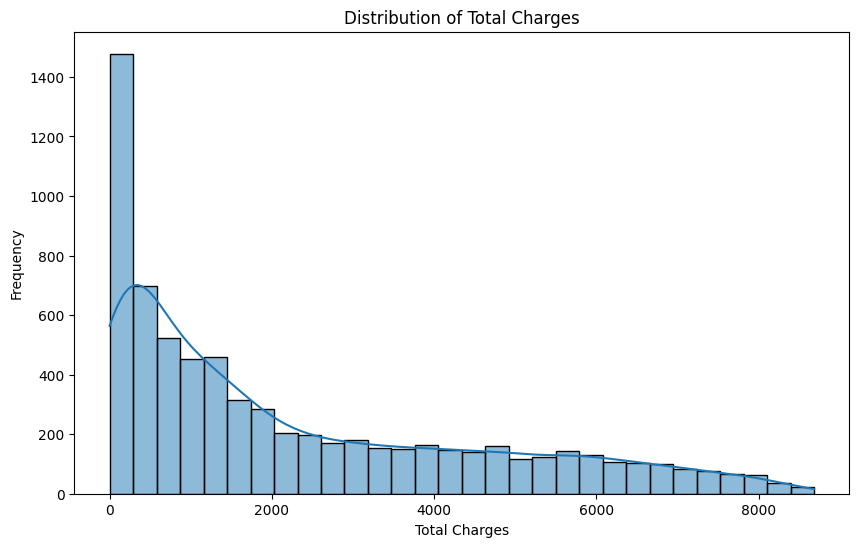

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(dataset['TotalCharges'], bins=30, kde=True)
plt.title('Distribution of Total Charges')
plt.xlabel('Total Charges')
plt.ylabel('Frequency')
plt.show()

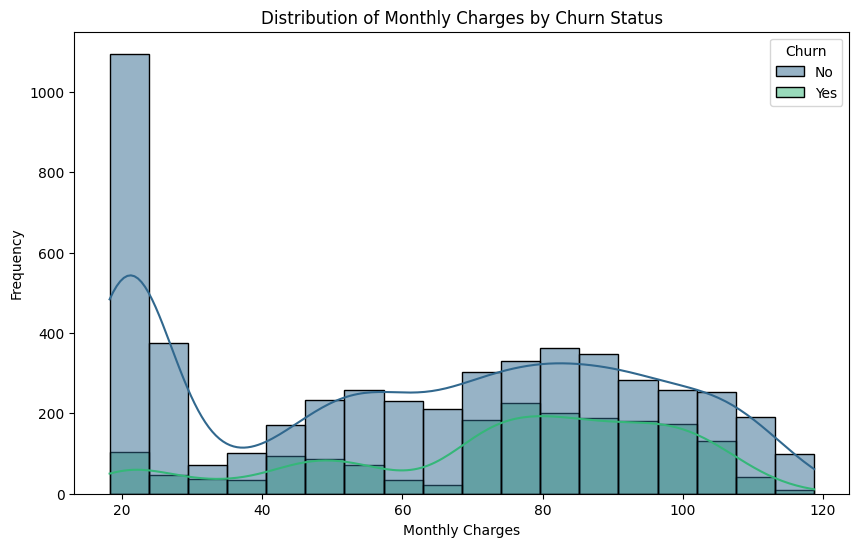

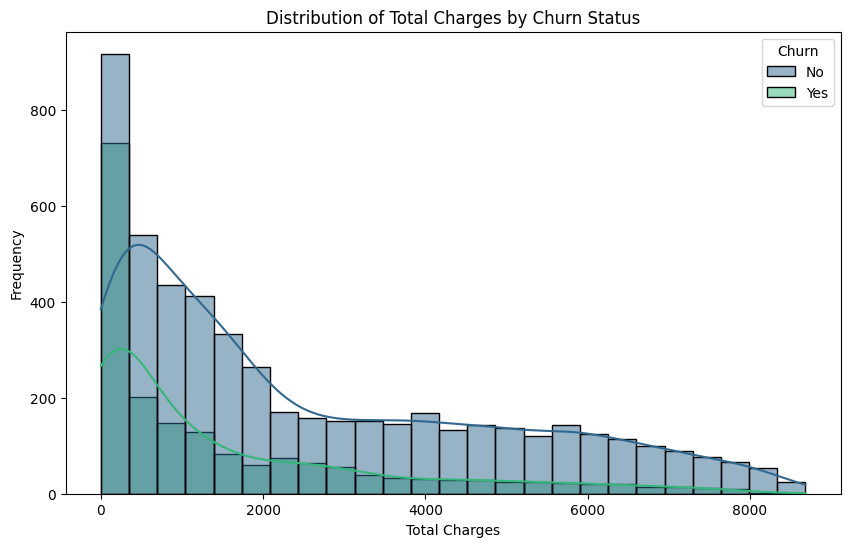

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=dataset, x='MonthlyCharges', hue='Churn', kde=True, palette='viridis')
plt.title('Distribution of Monthly Charges by Churn Status')
plt.xlabel('Monthly Charges')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(data=dataset, x='TotalCharges', hue='Churn', kde=True, palette='viridis')
plt.title('Distribution of Total Charges by Churn Status')
plt.xlabel('Total Charges')
plt.ylabel('Frequency')
plt.show()

### Tren Biaya Bulanan dan Total Biaya Selama Masa Berlaku Kontrak, Berdasarkan Jenis Kontrak

Bagian ini memvisualisasikan bagaimana `BiayaBulanan` dan `BiayaTotal` berubah seiring dengan `masa berlaku` (durasi layanan pelanggan) untuk pelanggan dengan kontrak 'Bulanan' dan 'Satu tahun'. Hal ini membantu memahami strategi penetapan harga dan nilai pelanggan dari waktu ke waktu.

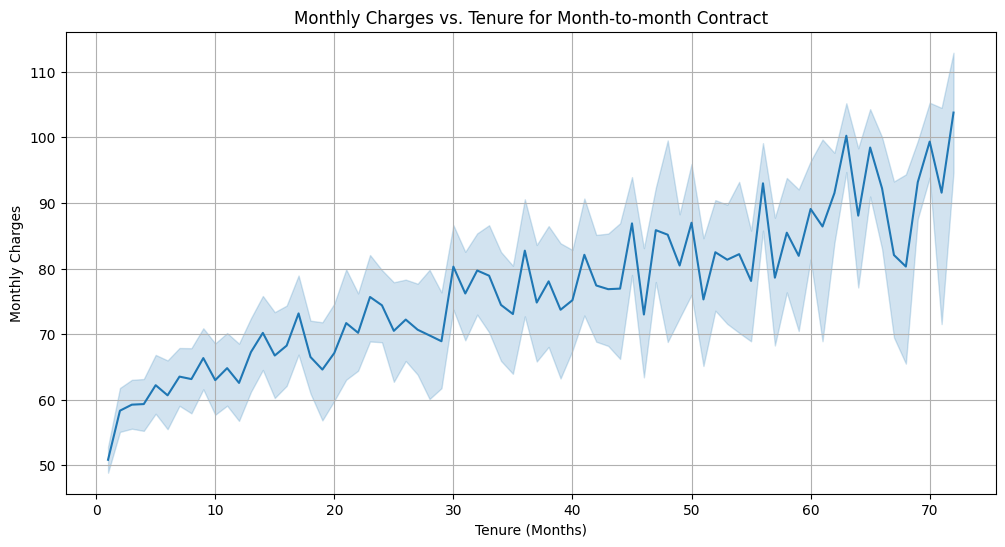

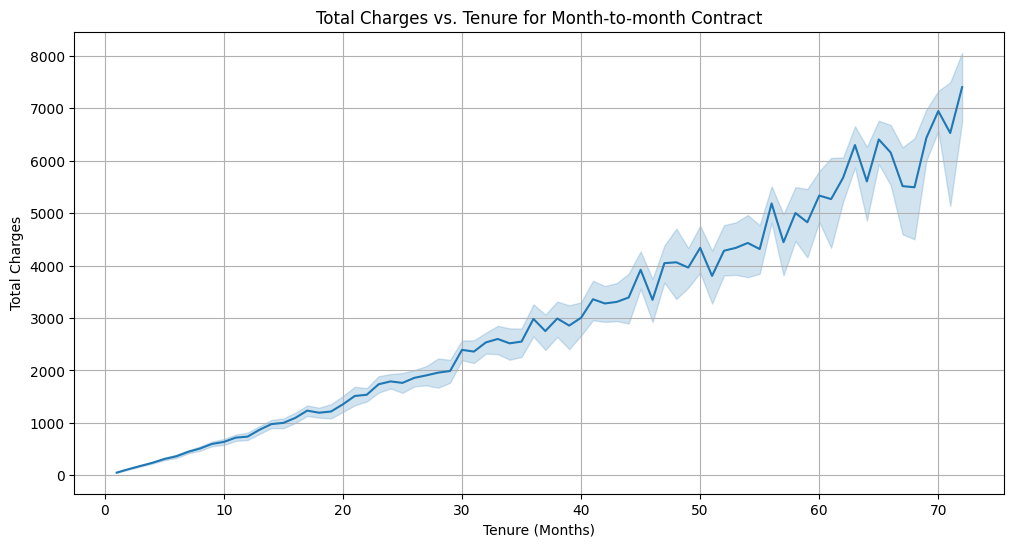

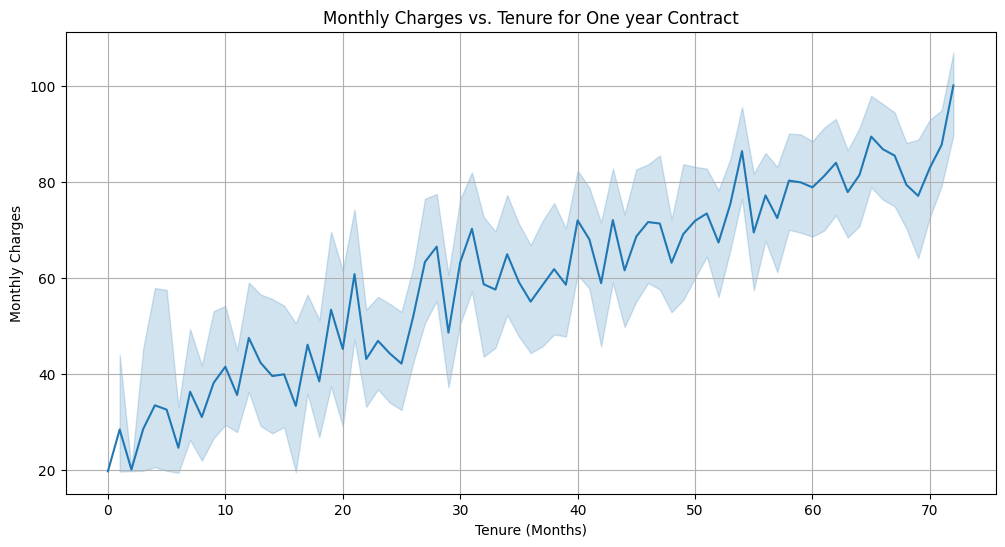

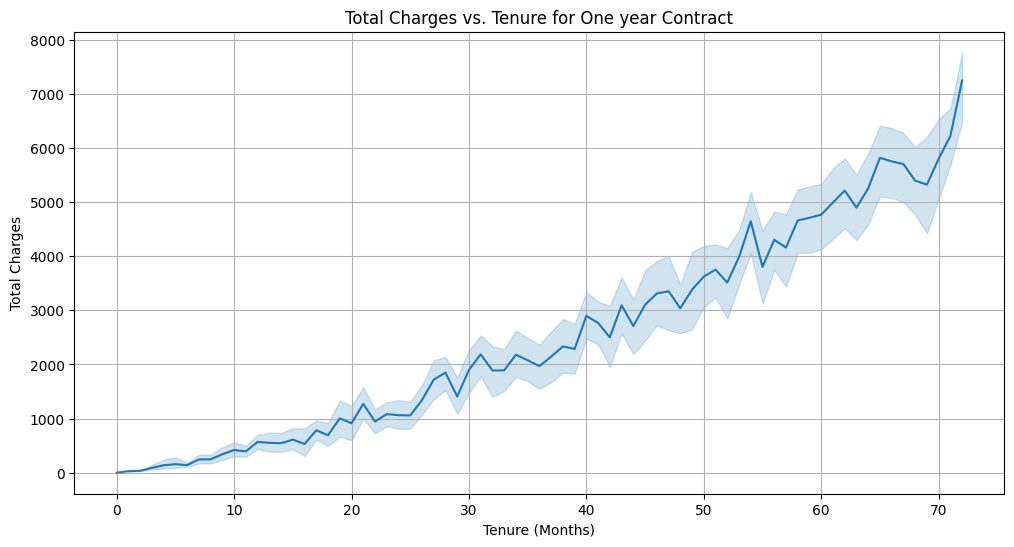

In [ ]:
contract_types = ['Month-to-month', 'One year']
df_filtered = dataset[dataset['Contract'].isin(contract_types)]

for contract_type in contract_types:
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=df_filtered[df_filtered['Contract'] == contract_type], x='tenure', y='MonthlyCharges')
    plt.title(f'Monthly Charges vs. Tenure for {contract_type} Contract')
    plt.xlabel('Tenure (Months)')
    plt.ylabel('Monthly Charges')
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(12, 6))
    sns.lineplot(data=df_filtered[df_filtered['Contract'] == contract_type], x='tenure', y='TotalCharges')
    plt.title(f'Total Charges vs. Tenure for {contract_type} Contract')
    plt.xlabel('Tenure (Months)')
    plt.ylabel('Total Charges')
    plt.grid(True)
    plt.show()

In [ ]:
dataset.groupby('Contract')['Contract'].value_counts()

,count
Contract,
Month-to-month,3875
One year,1473
Two year,1695


In [ ]:
dataset.groupby('PaymentMethod')['PaymentMethod'].value_counts()

,count
PaymentMethod,
Bank transfer (automatic),1544
Credit card (automatic),1522
Electronic check,2365
Mailed check,1612


In [ ]:
dataset.groupby('Contract')['Churn'].value_counts()

Contract        Churn
Month-to-month  No       2220
                Yes      1655
One year        No       1307
                Yes       166
Two year        No       1647
                Yes        48
Name: count, dtype: int64

In [ ]:
dataset_new

,customerID,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,PhoneService_No,PhoneService_Yes,MultipleLines_No,MultipleLines_No phone service,MultipleLines_Yes,InternetService_DSL,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0,1,29.85,29.85,No,1,0,0,1,1,0,1,0,0,1,0,1,0,0,1,0,0,0,0,1,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,1,0
1,5575-GNVDE,0,34,56.95,1889.50,No,0,1,1,0,1,0,0,1,1,0,0,1,0,0,0,0,1,1,0,0,0,0,1,1,0,0,1,0,0,1,0,0,0,1,0,1,0,0,0,0,1
2,3668-QPYBK,0,2,53.85,108.15,Yes,0,1,1,0,1,0,0,1,1,0,0,1,0,0,0,0,1,0,0,1,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,0,1
3,7795-CFOCW,0,45,42.30,1840.75,No,0,1,1,0,1,0,1,0,0,1,0,1,0,0,0,0,1,1,0,0,0,0,1,0,0,1,1,0,0,1,0,0,0,1,0,1,0,1,0,0,0
4,9237-HQITU,0,2,70.70,151.65,Yes,1,0,1,0,1,0,0,1,1,0,0,0,1,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,0,24,84.80,1990.50,No,0,1,0,1,0,1,0,1,0,0,1,1,0,0,0,0,1,1,0,0,0,0,1,0,0,1,0,0,1,0,0,1,0,1,0,0,1,0,0,0,1
7039,2234-XADUH,0,72,103.20,7362.90,No,1,0,0,1,0,1,0,1,0,0,1,0,1,0,1,0,0,0,0,1,0,0,1,1,0,0,0,0,1,0,0,1,0,1,0,0,1,0,1,0,0
7040,4801-JZAZL,0,11,29.60,346.45,No,1,0,0,1,0,1,1,0,0,1,0,1,0,0,0,0,1,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,1,0
7041,8361-LTMKD,1,4,74.40,306.60,Yes,0,1,0,1,1,0,0,1,0,0,1,0,1,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,0,1


In [ ]:
dataset_new.columns

Index(['customerID', 'SeniorCitizen', 'tenure', 'MonthlyCharges',
       'TotalCharges', 'Churn', 'gender_Female', 'gender_Male', 'Partner_No',
       'Partner_Yes', 'Dependents_No', 'Dependents_Yes', 'PhoneService_No',
       'PhoneService_Yes', 'MultipleLines_No',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_DSL', 'InternetService_Fiber optic',
       'InternetService_No', 'OnlineSecurity_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No', 'OnlineBackup_No internet service',
       'OnlineBackup_Yes', 'DeviceProtection_No',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No', 'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No', 'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No', 'StreamingMovies_No internet service',
       'StreamingMovies_Yes', 'Contract_Month-to-month', 'Contract_One year',
      

# SMOTE & Modelling

In [ ]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [ ]:
y_train_resampled.value_counts()

,count
Churn,
0,4138
1,4138


In [ ]:
y_train.value_counts()

,count
Churn,
0,4138
1,1496


# Modelling

In [ ]:
X = dataset_new.drop(['customerID', 'Churn'], axis=1)
y = dataset_new['Churn'].map({'Yes': 1, 'No': 0})


In [ ]:
X_train_resampled, X_test, y_train_resampled, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
    )

In [ ]:
y_train.value_counts(normalize=True)

,proportion
Churn,
0,0.734469
1,0.265531


In [ ]:
# Scalling Data
X_train

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,PhoneService_No,PhoneService_Yes,MultipleLines_No,MultipleLines_No phone service,MultipleLines_Yes,InternetService_DSL,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
2142,0,21,64.85,1336.80,1,0,1,0,0,1,0,1,1,0,0,1,0,0,0,0,1,1,0,0,0,0,1,1,0,0,1,0,0,0,0,1,0,1,0,1,0,0,0,0,1
1623,0,54,97.20,5129.45,1,0,1,0,1,0,0,1,0,0,1,0,1,0,1,0,0,0,0,1,1,0,0,1,0,0,0,0,1,0,0,1,0,0,1,0,1,1,0,0,0
6074,0,1,23.45,23.45,0,1,0,1,1,0,1,0,0,1,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,1,0
1362,0,4,70.20,237.95,0,1,1,0,1,0,0,1,1,0,0,0,1,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,1,0
6754,0,0,61.90,0.00,0,1,1,0,0,1,0,1,0,0,1,1,0,0,0,0,1,0,0,1,1,0,0,0,0,1,1,0,0,1,0,0,0,0,1,0,1,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3772,0,1,95.00,95.00,0,1,0,1,1,0,0,1,1,0,0,0,1,0,0,0,1,1,0,0,1,0,0,1,0,0,0,0,1,0,0,1,1,0,0,0,1,0,0,1,0
5191,0,23,91.10,2198.30,1,0,0,1,0,1,0,1,0,0,1,1,0,0,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,1,0,1,0,0
5226,0,12,21.15,306.05,0,1,0,1,0,1,0,1,1,0,0,0,0,1,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,1,0,0,0,1,0,0,1,0
5390,1,12,99.45,1200.15,0,1,1,0,1,0,0,1,0,0,1,0,1,0,1,0,0,1,0,0,0,0,1,1,0,0,0,0,1,0,0,1,1,0,0,0,1,0,0,1,0


In [ ]:
#ini diubah mengikuti distribusi

# Train
sc_X = StandardScaler()
X_tr_columns = X_train_resampled.columns
X_tr_idx = X_train_resampled.index
X_train_resampled = pd.DataFrame(
    sc_X.fit_transform(X_train),
    columns=X_tr_columns,
    index=X_tr_idx
)
# Test
X_ts_columns = X_test.columns
X_ts_idx = X_test.index
X_test = pd.DataFrame(
    sc_X.transform(X_test),
    columns=X_ts_columns,
    index=X_ts_idx
)

In [ ]:
X_train_resampled


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,PhoneService_No,PhoneService_Yes,MultipleLines_No,MultipleLines_No phone service,MultipleLines_Yes,InternetService_DSL,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
2142,-0.437749,-0.465683,-0.000474,-0.419925,1.025166,-1.025166,0.969579,-0.969579,-1.532186,1.532186,-0.329573,0.329573,1.04801,-0.329573,-0.860523,1.380442,-0.887057,-0.524081,-0.997518,-0.524081,1.580942,1.140820,-0.524081,-0.733828,-0.889615,-0.524081,1.384796,1.009273,-0.524081,-0.637763,1.231382,-0.524081,-0.794748,-0.807289,-0.524081,1.250762,-1.099339,1.910109,-0.558353,1.200007,-1.200007,-0.530678,-0.527656,-0.709650,1.84247
1623,-0.437749,0.885537,1.074754,1.256017,1.025166,-1.025166,0.969579,-0.969579,0.652662,-0.652662,-0.329573,0.329573,-0.95419,-0.329573,1.162083,-0.724405,1.127324,-0.524081,1.002488,-0.524081,-0.632534,-0.876562,-0.524081,1.362717,1.124082,-0.524081,-0.722128,1.009273,-0.524081,-0.637763,-0.812096,-0.524081,1.258260,-0.807289,-0.524081,1.250762,-1.099339,-0.523530,1.790982,-0.833328,0.833328,1.884380,-0.527656,-0.709650,-0.54275
6074,-0.437749,-1.284605,-1.376499,-1.000283,-0.975452,0.975452,-1.031376,1.031376,0.652662,-0.652662,3.034225,-3.034225,-0.95419,3.034225,-0.860523,1.380442,-0.887057,-0.524081,1.002488,-0.524081,-0.632534,1.140820,-0.524081,-0.733828,1.124082,-0.524081,-0.722128,1.009273,-0.524081,-0.637763,1.231382,-0.524081,-0.794748,1.238714,-0.524081,-0.799513,0.909638,-0.523530,-0.558353,-0.833328,0.833328,-0.530678,-0.527656,1.409146,-0.54275
1362,-0.437749,-1.161766,0.177346,-0.905497,-0.975452,0.975452,0.969579,-0.969579,0.652662,-0.652662,-0.329573,0.329573,1.04801,-0.329573,-0.860523,-0.724405,1.127324,-0.524081,1.002488,-0.524081,-0.632534,1.140820,-0.524081,-0.733828,1.124082,-0.524081,-0.722128,1.009273,-0.524081,-0.637763,1.231382,-0.524081,-0.794748,1.238714,-0.524081,-0.799513,0.909638,-0.523530,-0.558353,-0.833328,0.833328,-0.530678,-0.527656,1.409146,-0.54275
6754,-0.437749,-1.325551,-0.098524,-1.010646,-0.975452,0.975452,0.969579,-0.969579,-1.532186,1.532186,-0.329573,0.329573,-0.95419,-0.329573,1.162083,1.380442,-0.887057,-0.524081,-0.997518,-0.524081,1.580942,-0.876562,-0.524081,1.362717,1.124082,-0.524081,-0.722128,-0.990813,-0.524081,1.567981,1.231382,-0.524081,-0.794748,1.238714,-0.524081,-0.799513,-1.099339,-0.523530,1.790982,-0.833328,0.833328,1.884380,-0.527656,-0.709650,-0.54275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3772,-0.437749,-1.284605,1.001632,-0.968666,-0.975452,0.975452,-1.031376,1.031376,0.652662,-0.652662,-0.329573,0.329573,1.04801,-0.329573,-0.860523,-0.724405,1.127324,-0.524081,-0.997518,-0.524081,1.580942,1.140820,-0.524081,-0.733828,1.124082,-0.524081,-0.722128,1.009273,-0.524081,-0.637763,-0.812096,-0.524081,1.258260,-0.807289,-0.524081,1.250762,0.909638,-0.523530,-0.558353,-0.833328,0.833328,-0.530678,-0.527656,1.409146,-0.54275
5191,-0.437749,-0.383791,0.872006,-0.039235,1.025166,-1.025166,-1.031376,1.031376,-1.532186,1.532186,-0.329573,0.329573,-0.95419,-0.329573,1.162083,1.380442,-0.887057,-0.524081,-0.997518,-0.524081,1.580942,-0.876562,-0.524081,1.362717,-0.889615,

In [ ]:
models = []
models.append(
    (
        'Logistic Regression',
        LogisticRegression(
            solver='liblinear',
            random_state=42,
            class_weight='balanced'
        )
    )
)
models.append(
    (
        'Random Forest',
        RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            class_weight='balanced'
        )
    )
)
models.append(
    (
        'XGBoost',
        XGBClassifier(
            n_estimators=100,
            random_state=42,
            class_weight='balanced'
        )
    )
)
models.append(
    (
        'Decision Tree',
        DecisionTreeClassifier(
            random_state=42,
            class_weight='balanced'
        )
    )
)
models.append(
    (
        'Naive Bayes',
        GaussianNB()
    )
)
models.append(
    (
        'KNN',
        KNeighborsClassifier()
    )
)
models.append(
    (
        'SVM',
        SVC(
            random_state=42,
            class_weight='balanced'
        )
    )
)
models.append(
    (
        'LDA',
        LinearDiscriminantAnalysis()
    )
)

In [ ]:
#ment 1.04


acc_results = []
auc_results = []
names = []

col = ['Algorithm', 'ROC AUC Mean', 'ROC AUC STD', 'Accuracy Mean', 'Accuracy STD']
model_results = pd.DataFrame(columns = col)

# Convert y_train to numerical labels (0 and 1) for model compatibility
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)

i = 0
for name, model in models:
    kfold = KFold(n_splits = 10) # 10 Cross validation
    # Use the numerically encoded y_train
    cv_acc_results = cross_val_score(model, X_train_resampled, y_train_resampled, cv=kfold, scoring='accuracy')
    cv_auc_results = cross_val_score(model, X_train_resampled, y_train_resampled, cv=kfold, scoring='roc_auc')
    acc_results.append(cv_acc_results)
    auc_results.append(cv_auc_results)
    names.append(name)
    model_results.loc[i] =[
        name,
        round(cv_auc_results.mean() * 100, 2),
        round(cv_auc_results.std() * 100, 2),
        round(cv_acc_results.mean() * 100, 2),
        round(cv_acc_results.std() * 100, 2)
    ]
    i += 1
model_results.sort_values(
    by=['ROC AUC Mean'],
    ascending = False
)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist

,Algorithm,ROC AUC Mean,ROC AUC STD,Accuracy Mean,Accuracy STD
0,Logistic Regression,NaN,NaN,77.21,3.82
1,Random Forest,NaN,NaN,85.73,7.17
2,XGBoost,NaN,NaN,84.33,8.74
3,Decision Tree,NaN,NaN,77.47,5.48
4,Naive Bayes,NaN,NaN,74.76,7.02
5,KNN,NaN,NaN,77.54,9.68
6,SVM,NaN,NaN,81.32,5.37
7,LDA,NaN,NaN,74.28,2.28


In [ ]:
classifier_lr =  RandomForestClassifier(
            n_estimators=100,
            criterion='entropy',
            random_state=42
        )
classifier_lr.fit(X_train, y_train)
y_pred_lr = classifier_lr.predict(X_test)
cm_lr = confusion_matrix(y_test, y_pred_lr)
print(cm_lr)
print(classification_report(y_test, y_pred_lr))

[[1036    0]
 [ 373    0]]
              precision    recall  f1-score   support

           0       0.74      1.00      0.85      1036
           1       0.00      0.00      0.00       373

    accuracy                           0.74      1409
   macro avg       0.37      0.50      0.42      1409
weighted avg       0.54      0.74      0.62      1409



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
classifier_lr =  RandomForestClassifier(
            n_estimators=100,
            criterion='entropy',
            random_state=42
        )
classifier_lr.fit(X_train_resampled, y_train_resampled)
y_pred_lr = classifier_lr.predict(X_test)
cm_lr = confusion_matrix(y_test, y_pred_lr)
print(cm_lr)
print(classification_report(y_test, y_pred_lr))

[[1036    0]
 [ 373    0]]
              precision    recall  f1-score   support

           0       0.74      1.00      0.85      1036
           1       0.00      0.00      0.00       373

    accuracy                           0.74      1409
   macro avg       0.37      0.50      0.42      1409
weighted avg       0.54      0.74      0.62      1409



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
